In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

In [74]:
def plot_trajectory(traj_df, robot_name, axes, time_col='ros_time_sec', desired_color='blue', actual_color='orange'):
    # plot x position
    axes[0].plot(traj_df[time_col].to_numpy(), traj_df[f'des_{robot_name}_x'].to_numpy(), linestyle='--', color=desired_color)
    axes[0].plot(traj_df[time_col].to_numpy(), traj_df[f'act_{robot_name}_x'].to_numpy(), linestyle='-', color=actual_color)
    axes[0].set_ylabel("X Position (m)")
    axes[0].set_title(f"{robot_name} Trajectory")
    axes[0].legend()

    # plot y position
    axes[1].plot(traj_df[time_col].to_numpy(), traj_df[f'des_{robot_name}_y'].to_numpy(), linestyle='--', color=desired_color)
    axes[1].plot(traj_df[time_col].to_numpy(), traj_df[f'act_{robot_name}_y'].to_numpy(), linestyle='-', color=actual_color)
    axes[1].set_ylabel("Y Position (m)")
    axes[1].legend()
    
    # plot theta
    axes[2].plot(traj_df[time_col].to_numpy(), traj_df[f'des_{robot_name}_theta'].to_numpy(), linestyle='--', color=desired_color)
    axes[2].plot(traj_df[time_col].to_numpy(), traj_df[f'act_{robot_name}_theta'].to_numpy(), linestyle='-', color=actual_color)
    axes[2].set_ylabel("Theta (rad)")
    axes[2].legend()

In [75]:
def print_max_errors(traj_df):
    for robot in ['ross', 'mon']:
        print(f"{robot}:")
        max_x_error = np.max(np.abs(traj_df[f'des_{robot}_x'] - traj_df[f'act_{robot}_x']))
        max_y_error = np.max(np.abs(traj_df[f'des_{robot}_y'] - traj_df[f'act_{robot}_y']))
        max_theta_error = np.max(np.abs(traj_df[f'des_{robot}_theta'] - traj_df[f'act_{robot}_theta']))
        print(f"  Max X Error: {max_x_error:.4f} m")
        print(f"  Max Y Error: {max_y_error:.4f} m")
        print(f"  Max Theta Error: {max_theta_error:.4f} rad")

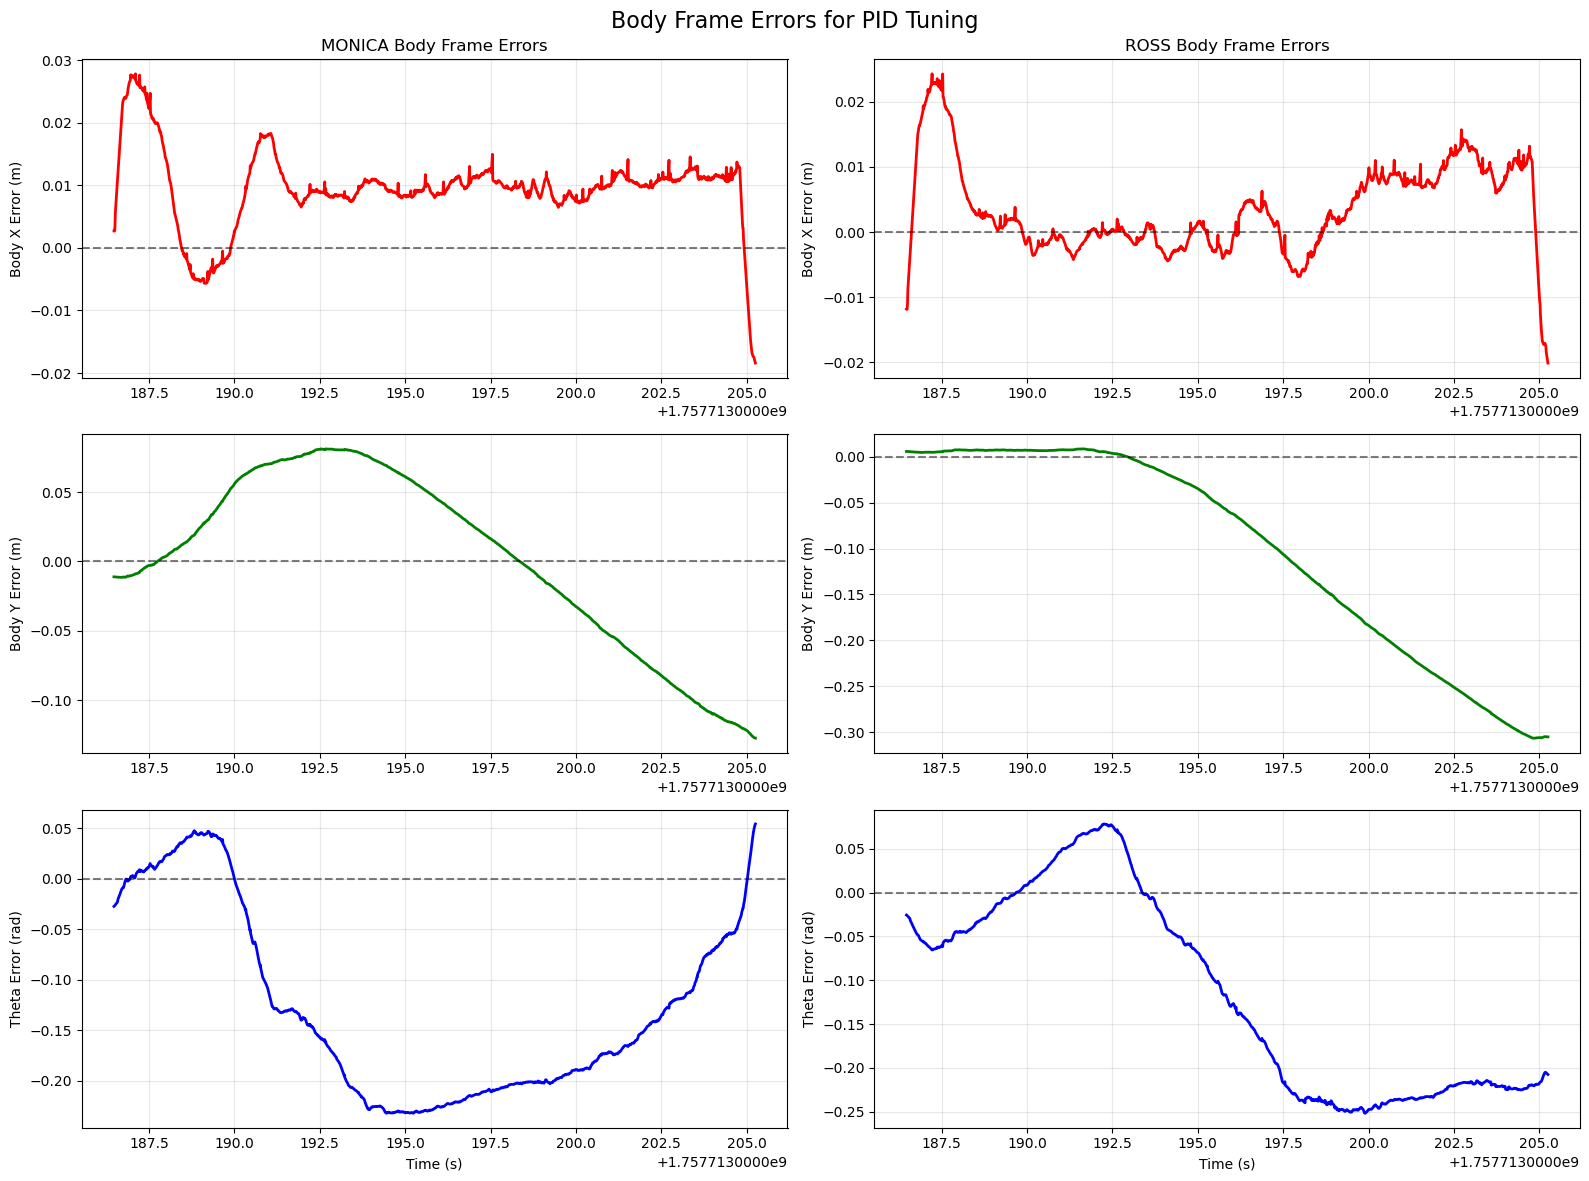

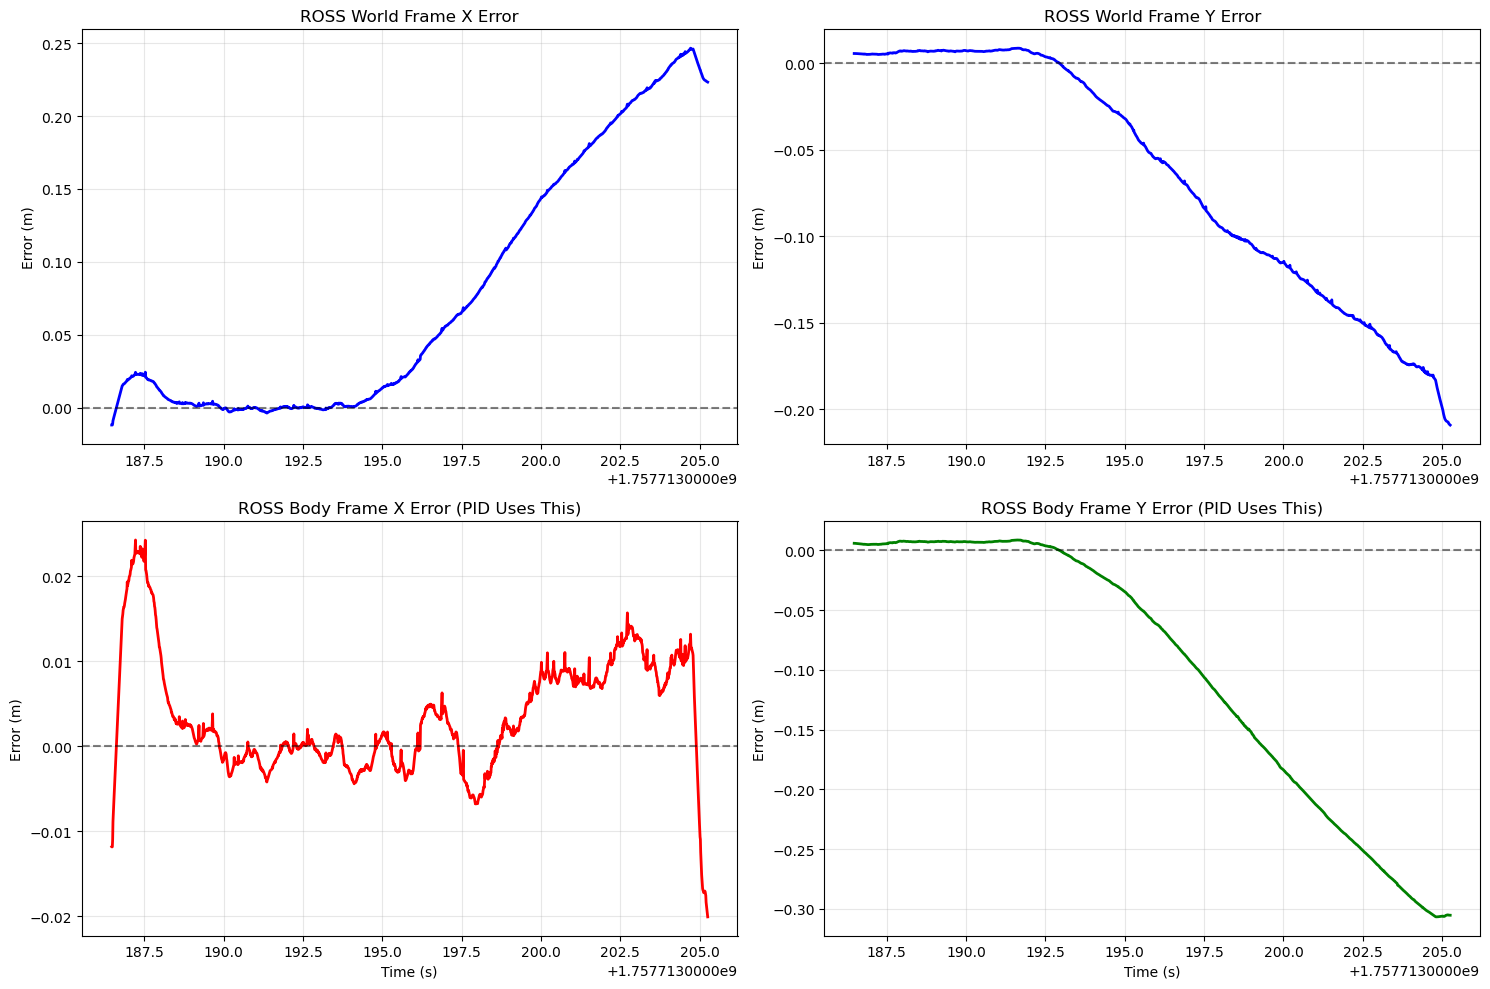

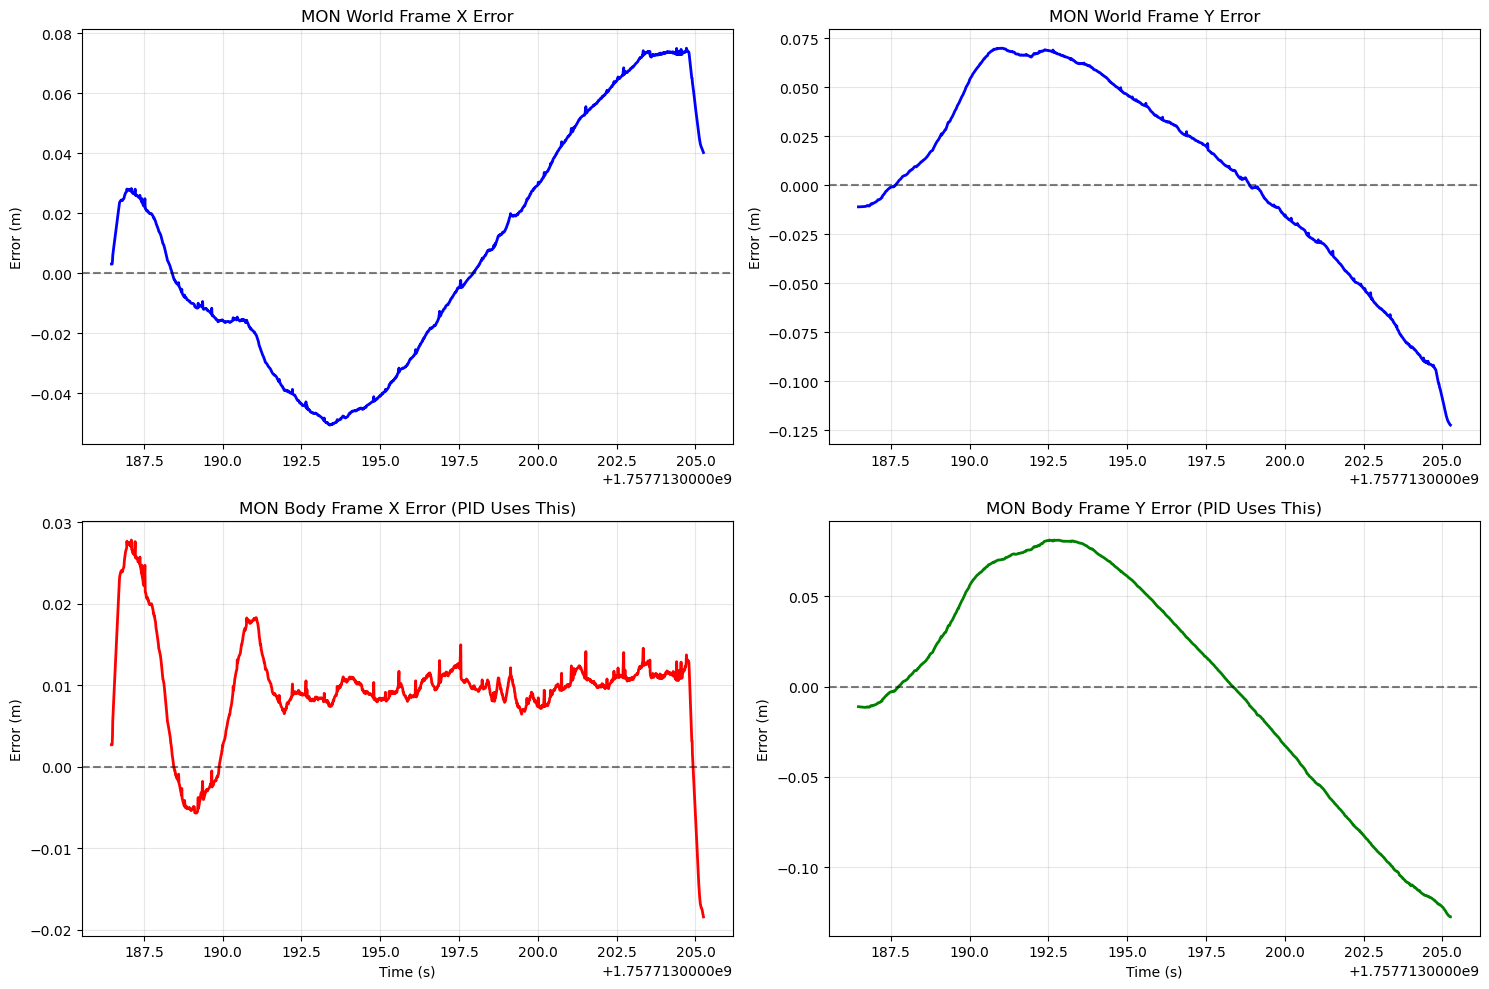

=== BODY FRAME ERROR STATISTICS (for PID tuning) ===

ROSS:
  Body X Error (forward/back):
    Max: 0.0243 m
    RMS: 0.0077 m
    Std: 0.0069 m
  Body Y Error (left/right):
    Max: 0.3067 m
    RMS: 0.1482 m
    Std: 0.1103 m
  Theta Error:
    Max: 0.2519 rad
    RMS: 0.1605 rad
    Std: 0.1125 rad

MON:
  Body X Error (forward/back):
    Max: 0.0278 m
    RMS: 0.0114 m
    Std: 0.0064 m
  Body Y Error (left/right):
    Max: 0.1274 m
    RMS: 0.0628 m
    Std: 0.0628 m
  Theta Error:
    Max: 0.2320 rad
    RMS: 0.1565 rad
    Std: 0.0918 rad


In [76]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

def calculate_body_frame_errors(traj_df):
    """Calculate body frame errors from world frame data"""
    # Ross body frame errors
    world_error_ross_x = traj_df['des_ross_x'] - traj_df['act_ross_x']
    world_error_ross_y = traj_df['des_ross_y'] - traj_df['act_ross_y']
    actual_theta_ross = traj_df['act_ross_theta']
    
    traj_df['body_error_ross_x'] = (world_error_ross_x * np.cos(actual_theta_ross) + 
                                   world_error_ross_y * np.sin(actual_theta_ross))
    traj_df['body_error_ross_y'] = (-world_error_ross_x * np.sin(actual_theta_ross) + 
                                   world_error_ross_y * np.cos(actual_theta_ross))
    
    # Monica body frame errors (note: actual_theta has +π added in C++ code)
    world_error_mon_x = traj_df['des_mon_x'] - traj_df['act_mon_x']
    world_error_mon_y = traj_df['des_mon_y'] - traj_df['act_mon_y']
    actual_theta_mon = traj_df['act_mon_theta']  # This already has +π from C++ code
    
    traj_df['body_error_mon_x'] = (world_error_mon_x * np.cos(actual_theta_mon) + 
                                  world_error_mon_y * np.sin(actual_theta_mon))
    traj_df['body_error_mon_y'] = (-world_error_mon_x * np.sin(actual_theta_mon) + 
                                  world_error_mon_y * np.cos(actual_theta_mon))
    
    return traj_df

def plot_body_frame_errors(traj_df, robot_name, axes, time_col='ros_time_sec'):
    """Plot body frame errors for PID tuning"""
    # Body frame X error (forward/backward)
    axes[0].plot(traj_df[time_col].to_numpy(), traj_df[f'body_error_{robot_name}_x'].to_numpy(), 'r-', linewidth=2)
    axes[0].set_ylabel("Body X Error (m)")
    axes[0].set_title(f"{robot_name.upper()} Body Frame Errors (for PID tuning)")
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Body frame Y error (left/right)
    axes[1].plot(traj_df[time_col].to_numpy(), traj_df[f'body_error_{robot_name}_y'].to_numpy(), 'g-', linewidth=2)
    axes[1].set_ylabel("Body Y Error (m)")
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Theta error (world frame - not transformed)
    world_theta_error = traj_df[f'des_{robot_name}_theta'].to_numpy() - traj_df[f'act_{robot_name}_theta'].to_numpy()
    axes[2].plot(traj_df[time_col].to_numpy(), world_theta_error, 'b-', linewidth=2)
    axes[2].set_ylabel("Theta Error (rad)")
    axes[2].set_xlabel("Time (s)")
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.5)

def plot_world_vs_body_comparison(traj_df, robot_name, time_col='ros_time_sec'):
    """Compare world frame vs body frame errors"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # World frame errors
    world_error_x = traj_df[f'des_{robot_name}_x'].to_numpy() - traj_df[f'act_{robot_name}_x'].to_numpy()
    world_error_y = traj_df[f'des_{robot_name}_y'].to_numpy() - traj_df[f'act_{robot_name}_y'].to_numpy()

    axes[0, 0].plot(traj_df[time_col].to_numpy(), world_error_x, 'b-', linewidth=2)
    axes[0, 0].set_title(f'{robot_name.upper()} World Frame X Error')
    axes[0, 0].set_ylabel('Error (m)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    axes[0, 1].plot(traj_df[time_col].to_numpy(), world_error_y, 'b-', linewidth=2)
    axes[0, 1].set_title(f'{robot_name.upper()} World Frame Y Error')
    axes[0, 1].set_ylabel('Error (m)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Body frame errors
    axes[1, 0].plot(traj_df[time_col].to_numpy(), traj_df[f'body_error_{robot_name}_x'].to_numpy(), 'r-', linewidth=2)
    axes[1, 0].set_title(f'{robot_name.upper()} Body Frame X Error (PID Uses This)')
    axes[1, 0].set_ylabel('Error (m)')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    axes[1, 1].plot(traj_df[time_col].to_numpy(), traj_df[f'body_error_{robot_name}_y'].to_numpy(), 'g-', linewidth=2)
    axes[1, 1].set_title(f'{robot_name.upper()} Body Frame Y Error (PID Uses This)')
    axes[1, 1].set_ylabel('Error (m)')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    return fig

def print_body_frame_error_stats(traj_df):
    """Print body frame error statistics for PID tuning"""
    print("=== BODY FRAME ERROR STATISTICS (for PID tuning) ===")
    for robot in ['ross', 'mon']:
        print(f"\n{robot.upper()}:")
        
        body_x_error = traj_df[f'body_error_{robot}_x']
        body_y_error = traj_df[f'body_error_{robot}_y']
        theta_error = traj_df[f'des_{robot}_theta'] - traj_df[f'act_{robot}_theta']
        
        print(f"  Body X Error (forward/back):")
        print(f"    Max: {np.max(np.abs(body_x_error)):.4f} m")
        print(f"    RMS: {np.sqrt(np.mean(body_x_error**2)):.4f} m")
        print(f"    Std: {np.std(body_x_error):.4f} m")
        
        print(f"  Body Y Error (left/right):")
        print(f"    Max: {np.max(np.abs(body_y_error)):.4f} m")
        print(f"    RMS: {np.sqrt(np.mean(body_y_error**2)):.4f} m")
        print(f"    Std: {np.std(body_y_error):.4f} m")
        
        print(f"  Theta Error:")
        print(f"    Max: {np.max(np.abs(theta_error)):.4f} rad")
        print(f"    RMS: {np.sqrt(np.mean(theta_error**2)):.4f} rad")
        print(f"    Std: {np.std(theta_error):.4f} rad")

# Main analysis
trial_name = 'test_trial'
file_path = f'../data/{trial_name}/trajectory_data.csv'
time_col = 'ros_time_sec'

traj_df = pd.read_csv(file_path)

# Calculate body frame errors
traj_df = calculate_body_frame_errors(traj_df)

# Plot body frame errors for PID tuning
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Body Frame Errors for PID Tuning', fontsize=16)

plot_body_frame_errors(traj_df, 'mon', axes[:, 0])
plot_body_frame_errors(traj_df, 'ross', axes[:, 1])

axes[0, 0].set_title('MONICA Body Frame Errors')
axes[0, 1].set_title('ROSS Body Frame Errors')

plt.tight_layout()
plt.show()

# Show comparison between world and body frame errors
plot_world_vs_body_comparison(traj_df, 'ross')
plt.show()

plot_world_vs_body_comparison(traj_df, 'mon')
plt.show()

# Print statistics
print_body_frame_error_stats(traj_df)